In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import pysr
from pysr import PySRRegressor

import sys
import os
import argparse
import glob

workdir = os.getenv('WORKDIR')
sys.path.append(f'{workdir}/src')

from handlers import trainer, evaluation, annealing, sr_trainer, visualizer
from handlers.args import setup_argparse
from handlers.model_loader import TorchLoader, SurrogateLoader

from ml_utils import losses
from ml_utils import surrogates
from ml_utils.optimizers import optim

from metrics import complexity, faithfulness

from preprocessing.dataloaders import train_load, test_load
from preprocessing.datasets import SimpleIterDataset

from postprocessing.io_writer import _write_outputs_to_root

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import mplhep as mh
plt.style.use(mh.style.CMS)

from importlib.util import spec_from_file_location, module_from_spec

from weaver.utils.logger import _logger, warn_n_times, _configLogger
import copy
from pprint import pformat
import time
from collections import defaultdict

from main import assemble_loaders

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
workdir = os.getenv('WORKDIR')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
class Args:
    def __init__(self, **kwargs):
        # defaults
        self.data_train = []
        self.data_test = []
        self.data_val = []
        self.num_workers = 0
        self.num_epochs = 0
        self.data_config = ''
        self.file_fraction = 1
        self.data_fraction = 1
        self.batch_size = 0
        self.local_rank = None
        self.model_prefix = None
        self.lr_finder = None
        self.optimizer_option = []
        self.optimizer = 'ranger'
        self.start_lr = 1e-3
        self.final_lr = 1e-6
        self.lr_scheduler = 'flat+decay'
        self.kl_weight = 0.1
        self.class_weight = 1.0
        self.kl_anneal = False
        self.alpha = 0
        self.beta = 0
        self.gamma = 0
        self.bit_size = None
        self.dr_path = None
        self.dr_network = None
        
        for key, value in kwargs.items():
            setattr(self, key, value)

In [4]:
signals = [
    'TTBar',
    'WToQQ',
    'HToGG'
]

jc_paths = {
    'train': f'{workdir}/datasets/JetClass/Pythia/train_100M',
    'val': f'{workdir}/datasets/JetClass/Pythia/val_5M',
    'test': f'{workdir}/datasets/JetClass/Pythia/test_20M'
}

num_classes = 2
background = '/ZJetsToNuNu_*.root'

datasets = {signal: {} for signal in signals}

for signal in signals:
    for name, path in jc_paths.items():
    
        signal_glob = f'/{signal}_*.root'
        signal_files = glob.glob(path+signal_glob)
        background_files = glob.glob(path+background)
    
        datasets[signal][name] = signal_files + background_files

In [5]:
model_dir = f'{workdir}/outputs/models'
sr_dir = f'{workdir}/outputs/sr_runs'

config_paths = {signal: f'{workdir}/data_config/JetClass/JetClass_{signal}.yaml' for signal in signals}

In [6]:
def register_models(signal):
    model_registry = {
        'TTBar': [
            TorchLoader(
                model_name='KD-ParT',
                teacher_name='PELICAN',
                network_path=f'{workdir}/wrappers/part_wrapper.py',
                model_path=f'{model_dir}/TTBar/ParT/ParT_M4-PARTKD_KD_PELICAN_3_epoch-4_state.pt',
                data_config=config_paths['TTBar']
            ),
            TorchLoader(
                model_name='A-ParT',
                teacher_name=None,
                network_path=f'{workdir}/wrappers/part_wrapper.py',
                model_path=f'{model_dir}/TTBar/ParT/ParT_M1-CONTROL_DL_epoch-4_state.pt',
                data_config=config_paths['TTBar']
            ),
            SurrogateLoader(
                model_name='KD-ParT-S',
                teacher_name='KD-ParT',
                vae_network=f'{workdir}/wrappers/vae.py',
                vae_path=f'{model_dir}/TTBar/BVAE/BVAE_M6-BVAE_DR_epoch-4_state.pt',
                data_config=config_paths['TTBar'],
                sr_path=f'{sr_dir}/TTBar/Surrogate/Surrogate_M7-SRPART_ParT_BVAE_SR',
                equations=[27, 18]
            ),
            SurrogateLoader(
                model_name='A-ParT-S',
                teacher_name='A-ParT',
                vae_network=f'{workdir}/wrappers/vae.py',
                vae_path=f'{model_dir}/TTBar/BVAE/BVAE_M6-BVAE_DR_epoch-4_state.pt',
                data_config=config_paths['TTBar'],
                sr_path=f'{sr_dir}/TTBar/Surrogate/Surrogate_A1-TEACHERLESSPART_ParT_BVAE_SR',
                equations=[21, 13]
            )
        ],
        'WToQQ': [
            TorchLoader(
                model_name='KD-ParT',
                teacher_name='PELICAN',
                network_path=f'{workdir}/wrappers/part_wrapper.py',
                model_path=f'{model_dir}/WToQQ/ParT/ParT_M4-PARTKD_KD_PELICAN_7_epoch-4_state.pt',
                data_config=config_paths['WToQQ']
            ),
            TorchLoader(
                model_name='A-ParT',
                teacher_name=None,
                network_path=f'{workdir}/wrappers/part_wrapper.py',
                model_path=f'{model_dir}/WToQQ/ParT/ParT_M1-CONTROL_DL_epoch-4_state.pt',
                data_config=config_paths['WToQQ']
            ),
            SurrogateLoader(
                model_name='KD-ParT-S',
                teacher_name='KD-ParT',
                vae_network=f'{workdir}/wrappers/vae.py',
                vae_path=f'{model_dir}/WToQQ/BVAE/BVAE_M6-BVAE_DR_epoch-4_state.pt',
                data_config=config_paths['WToQQ'],
                sr_path=f'{sr_dir}/WToQQ/Surrogate/Surrogate_M7-SRPART_ParT_BVAE_SR',
                equations=[21, 25]
            ),
            SurrogateLoader(
                model_name='A-ParT-S',
                teacher_name='A-ParT',
                vae_network=f'{workdir}/wrappers/vae.py',
                vae_path=f'{model_dir}/WToQQ/BVAE/BVAE_M6-BVAE_DR_epoch-4_state.pt',
                data_config=config_paths['WToQQ'],
                sr_path=f'{sr_dir}/WToQQ/Surrogate/Surrogate_A1-TEACHERLESSPART_ParT_BVAE_SR',
                equations=[17, 18]
            )
        ],
        'HToGG': [
            TorchLoader(
                model_name='KD-ParT',
                teacher_name='PELICAN',
                network_path=f'{workdir}/wrappers/part_wrapper.py',
                model_path=f'{model_dir}/HToGG/ParT/ParT_M4-PARTKD_KD_PELICAN_5_epoch-4_state.pt',
                data_config=config_paths['HToGG']
            ),
            TorchLoader(
                model_name='A-ParT',
                teacher_name=None,
                network_path=f'{workdir}/wrappers/part_wrapper.py',
                model_path=f'{model_dir}/HToGG/ParT/ParT_M1-CONTROL_DL_epoch-4_state.pt',
                data_config=config_paths['HToGG']
            ),
            SurrogateLoader(
                model_name='KD-ParT-S',
                teacher_name='KD-ParT',
                vae_network=f'{workdir}/wrappers/vae.py',
                vae_path=f'{model_dir}/HToGG/BVAE/BVAE_M6-BVAE_DR_epoch-4_state.pt',
                data_config=config_paths['HToGG'],
                sr_path=f'{sr_dir}/HToGG/Surrogate/Surrogate_M7-SRPART_ParT_BVAE_SR',
                equations=[19, 17]
            ),
            SurrogateLoader(
                model_name='A-ParT-S',
                teacher_name='A-ParT',
                vae_network=f'{workdir}/wrappers/vae.py',
                vae_path=f'{model_dir}/HToGG/BVAE/BVAE_M6-BVAE_DR_epoch-4_state.pt',
                data_config=config_paths['HToGG'],
                sr_path=f'{sr_dir}/HToGG/Surrogate/Surrogate_A1-TEACHERLESSPART_ParT_BVAE_SR',
                equations=[18, 16]
            )
        ]
    }

    return model_registry[signal]

In [7]:
_model_dicts = {signal: {} for signal in signals}

for signal in signals:
    print(f'WORKING ON: {signal}')
    models = register_models(signal)

    yaml_config = f'{workdir}/data_config/JetClass/JetClass_{signal}.yaml'
    args = Args(
        data_train = datasets[signal]['train'],
        data_val = datasets[signal]['val'],
        data_test = datasets[signal]['test'],
        data_config = yaml_config,
        batch_size = 128,
        file_fraction = 1,
        data_fraction = 0.1,
    )

    loss_fn = torch.nn.CrossEntropyLoss()

    loader_dict = assemble_loaders(args)
    
    for model_loader in models:
        model = copy.deepcopy(model_loader.load()).to(device)
        name = model_loader.get_label()
        print(f'Currently working on {name}')
        tester = evaluation.ClassificationStats(
            loss_fn,
            model=model,
            device=device,
            loader=loader_dict['test'],
            split='test'
        )
        print(f'Initialized Classification Stats for {name}')

        with torch.no_grad():
            test_dict = tester.run()
        if isinstance(model_loader, SurrogateLoader):
            test_dict['complexity']['num_params'][0] -= complexity.total_params(model.dr)[0]
        _model_dicts[signal][name] = test_dict

        del model
        del model_loader
        torch.cuda.empty_cache()

WORKING ON: TTBar
Currently working on KD-ParT
Initialized Classification Stats for KD-ParT


0it [00:00, ?it/s]

=== Restarting DataIter test_, seed=None ===


/home/alang/anaconda3/envs/part_gp/lib/python3.10/site-packages/weaver/nn/model/ParticleTransformer.py:549: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.use_amp):
/home/alang/anaconda3/envs/part_gp/lib/python3.10/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
3125it [06:29,  8.02it/s, Loss=0.13401, Acc=0.92188, Avg Accuracy=0.94315, Avg Loss=0.14362]
/home/alang/ppCodes/part_gp/src/handlers/evaluation.py:161: RuntimeWarning: divide by zero encountered in divide
  self.output_dict['classification']['bkg_rejs'] = 1/fpr


Currently working on A-ParT
Initialized Classification Stats for A-ParT


...

3125it [05:27,  9.54it/s, Loss=0.41298, Acc=0.81250, Avg Accuracy=0.83611, Avg Loss=0.38390]
/home/alang/ppCodes/part_gp/src/handlers/evaluation.py:161: RuntimeWarning: divide by zero encountered in divide
  self.output_dict['classification']['bkg_rejs'] = 1/fpr
Attempting to load model from /home/alang/ppCodes/part_gp/outputs/sr_runs/HToGG/Surrogate/Surrogate_A1-TEACHERLESSPART_ParT_BVAE_SR/checkpoint.pkl...


Currently working on A-ParT-S
Initialized Classification Stats for A-ParT-S


0it [00:00, ?it/s]

=== Restarting DataIter test_, seed=None ===


3125it [05:25,  9.61it/s, Loss=0.37746, Acc=0.82812, Avg Accuracy=0.84064, Avg Loss=0.38324]
/home/alang/ppCodes/part_gp/src/handlers/evaluation.py:161: RuntimeWarning: divide by zero encountered in divide
  self.output_dict['classification']['bkg_rejs'] = 1/fpr


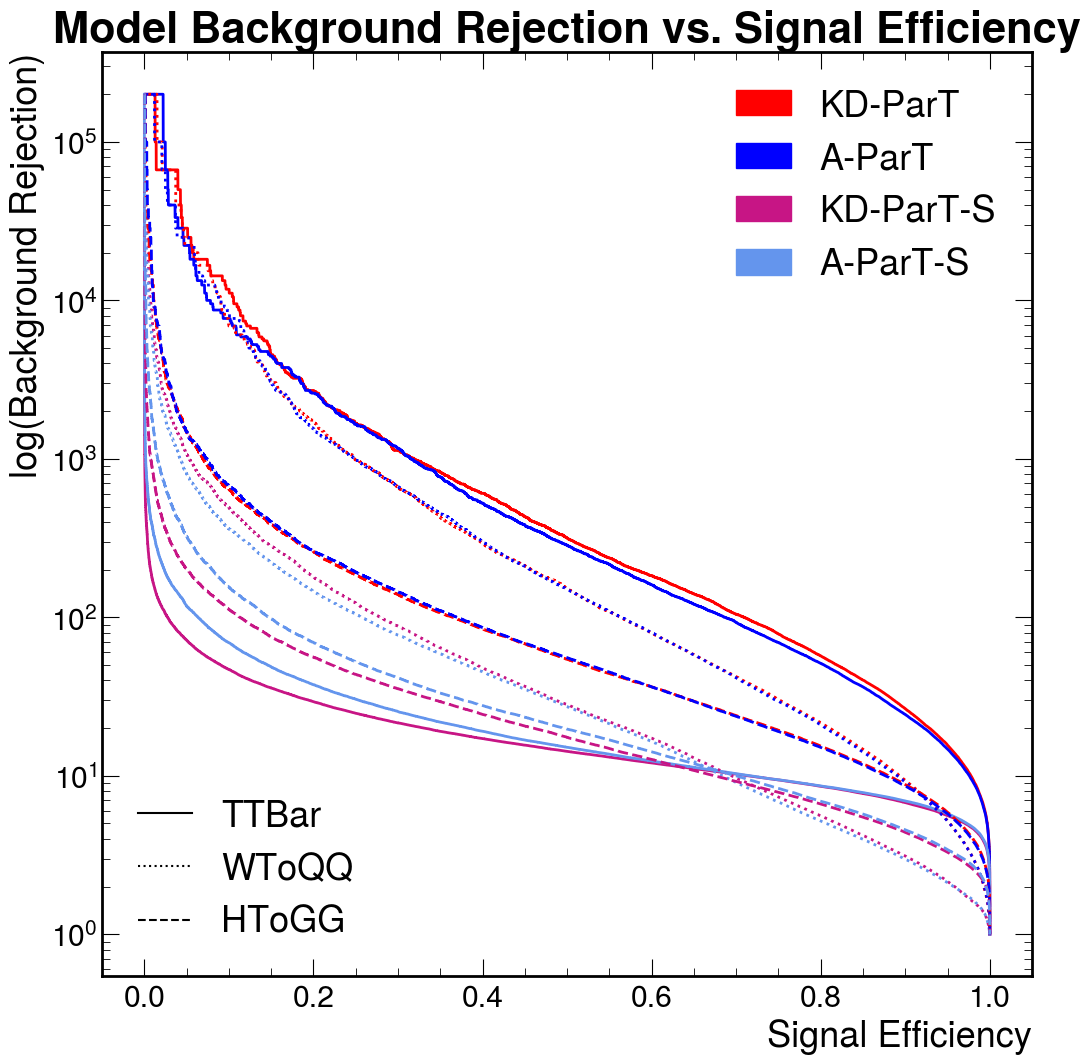

In [8]:
from matplotlib.lines import Line2D
import matplotlib.patches as patches

signal_lines = {
    'TTBar': '-',
    'WToQQ': ':',
    'HToGG': '--'
}

model_colors = {
    'KD-ParT': 'red',
    'A-ParT': 'blue',
    'KD-ParT-S': 'mediumvioletred',
    'A-ParT-S': 'cornflowerblue',
}

fig, ax = plt.subplots(figsize=(12, 12))

for signal, models in _model_dicts.items():
    for model_name, data_dict in models.items():
        sig_eff = data_dict['classification']['tpr']
        bkg_rej = data_dict['classification']['bkg_rejs']

        ax.plot(sig_eff, 
                   bkg_rej, 
                   linestyle=signal_lines[signal], 
                   color=model_colors[model_name],
                   linewidth=2
                  )

ax.set_yscale('log')
ax.set_title('Model Background Rejection vs. Signal Efficiency', fontweight='bold')
ax.set_xlabel(r'Signal Efficiency')
ax.set_ylabel(r'log(Background Rejection)')

custom_lines = []

for signal, linetype in signal_lines.items():
    custom_lines.append(Line2D([0], [0], linestyle=linetype, color='black', label=signal))

signals_legend = ax.legend(handles=custom_lines, loc='lower left', prop={'size': 'medium'})
ax.add_artist(signals_legend)

custom_colors = []

for name, color in model_colors.items():
    custom_colors.append(patches.Patch(color=color, label=name))

ax.legend(handles=custom_colors, loc='upper right', prop={'size': 'medium'})

plt.show()
#fig.savefig(f'{workdir}/figures/M15-COMPARISON_bkgrejs.png', dpi=300, format='png')

In [24]:
_model_dicts['TTBar']['KD-ParT-S']['preds']['logits'].max()

2334.7559

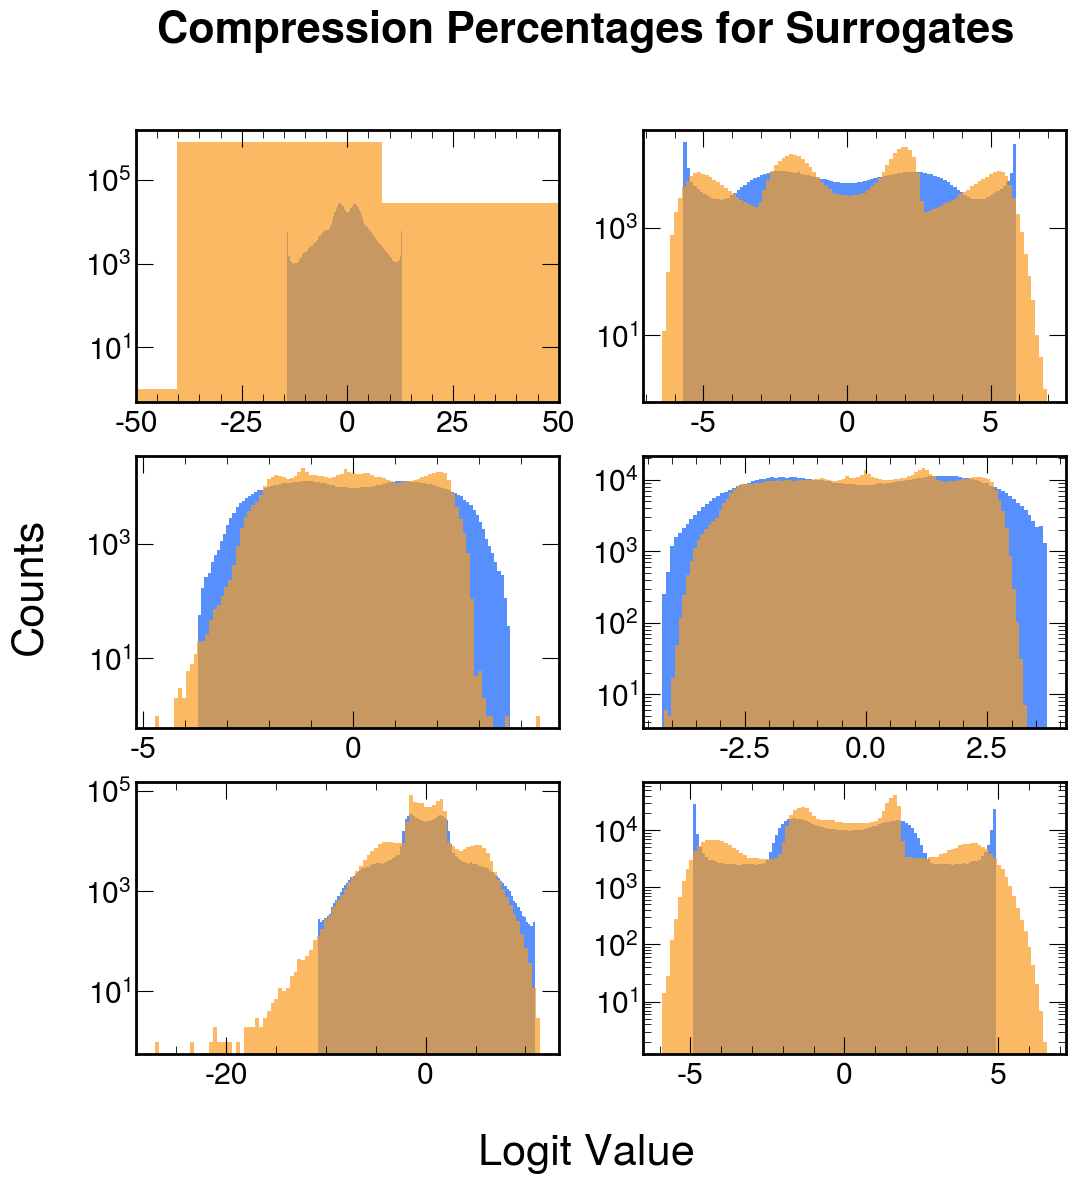

In [31]:
fig, ax = plt.subplots(ncols=2, nrows=3, figsize=(12, 12))

surrogates = ['KD-ParT-S', 'A-ParT-S']

model_colors = {
    'KD-ParT': 'red',
    'A-ParT': 'blue',
    'KD-ParT-S': 'mediumvioletred',
    'A-ParT-S': 'cornflowerblue',
}

signal_row={
    'TTBar': 0,
    'WToQQ': 1,
    'HToGG': 2
}

for signal, models in _model_dicts.items():
    for model_name, data_dict in models.items():
        if model_name not in surrogates:
            continue

        dl_name = model_name[:-2]
        dl_logits = models[dl_name]['preds']['logits'].flatten()
        model_logits = data_dict['preds']['logits'].flatten()

        if model_name.startswith('KD-'):
            col = 0
        elif model_name.startswith('A-'):
            col = 1

        ax[signal_row[signal], col].hist(dl_logits, bins=100, label=dl_name, alpha= 1)
        ax[signal_row[signal], col].hist(model_logits, bins=100, label=model_name, alpha=0.7)
        ax[signal_row[signal], col].set_yscale('log')

fig.suptitle('Compression Percentages for Surrogates', fontweight='bold')
fig.supxlabel(r'Logit Value')
fig.supylabel(r'Counts')

ax[0, 0].set_xlim(-50, 50)

#plt.legend(loc='lower right', bbox_to_anchor=(1, -0.6))

plt.show()
#fig.savefig(f'{workdir}/figures/M15-COMPARISON_compressions.png', dpi=300, format='png')

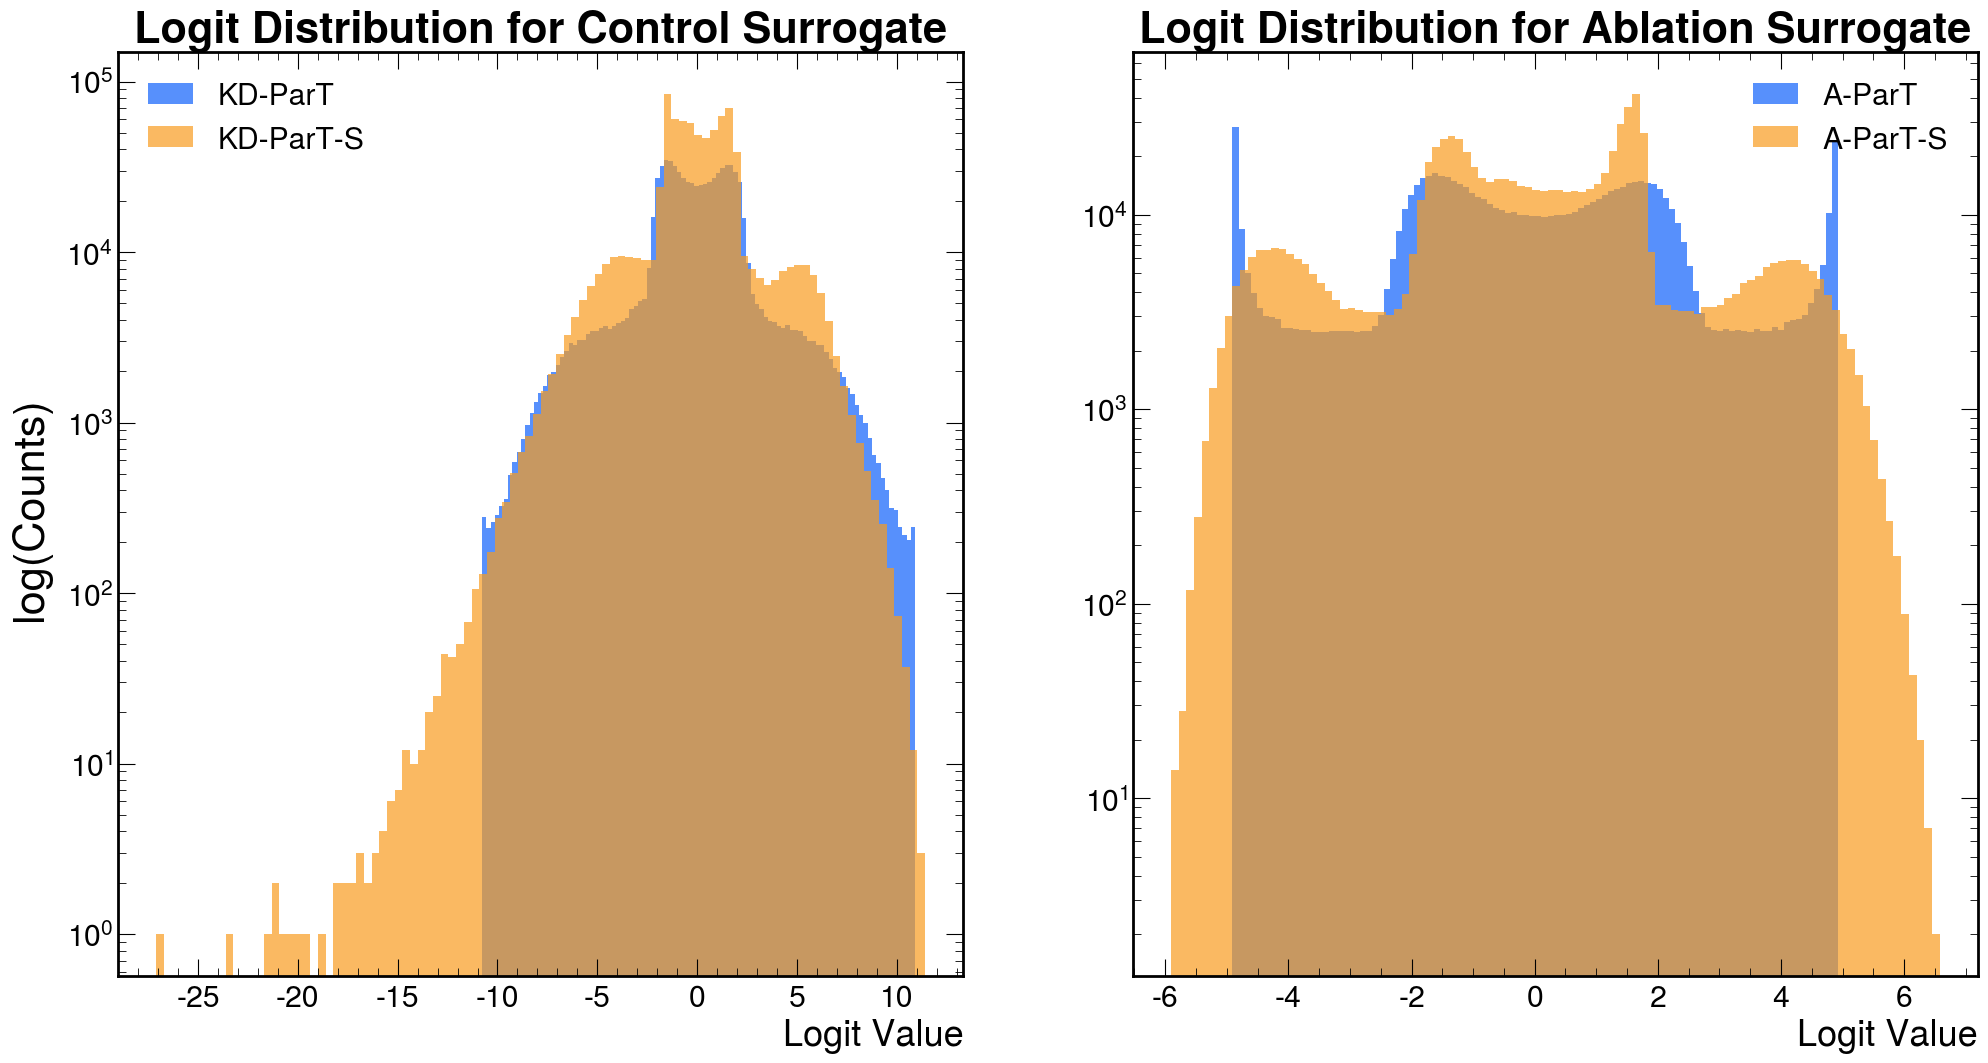

In [63]:
fig, ax = plt.subplots(ncols=2, figsize=(24, 12))

surrogates = ['KD-ParT-S', 'A-ParT-S']

model_colors = {
    'KD-ParT': 'red',
    'A-ParT': 'blue',
    'KD-ParT-S': 'mediumvioletred',
    'A-ParT-S': 'cornflowerblue',
}

signal_row={
    'TTBar': 0,
    'WToQQ': 1,
    'HToGG': 2
}

for signal, models in _model_dicts.items():
    if signal != 'HToGG':
        continue
    for model_name, data_dict in models.items():
        if model_name not in surrogates:
            continue

        dl_name = model_name[:-2]
        dl_logits = models[dl_name]['preds']['logits'].flatten()
        model_logits = data_dict['preds']['logits'].flatten()

        if model_name.startswith('KD-'):
            col = 0
        elif model_name.startswith('A-'):
            col = 1

        ax[col].hist(dl_logits, bins=100, label=dl_name, alpha=1)
        ax[col].hist(model_logits, bins=100, label=model_name, alpha=0.7)
        ax[col].set_yscale('log')

ax[0].set_title('Logit Distribution for Control Surrogate', fontweight='bold')
ax[1].set_title('Logit Distribution for Ablation Surrogate', fontweight='bold')
ax[0].set_xlabel(r'Logit Value')
ax[1].set_xlabel(r'Logit Value')
fig.supylabel(r'log(Counts)', x = 0.08)

ax[0].legend()
ax[1].legend()

#plt.legend(loc='lower right', bbox_to_anchor=(1, -0.6))

plt.show()
#fig.savefig(f'{workdir}/figures/M15-COMPARISON_compressions.png', dpi=300, format='png')

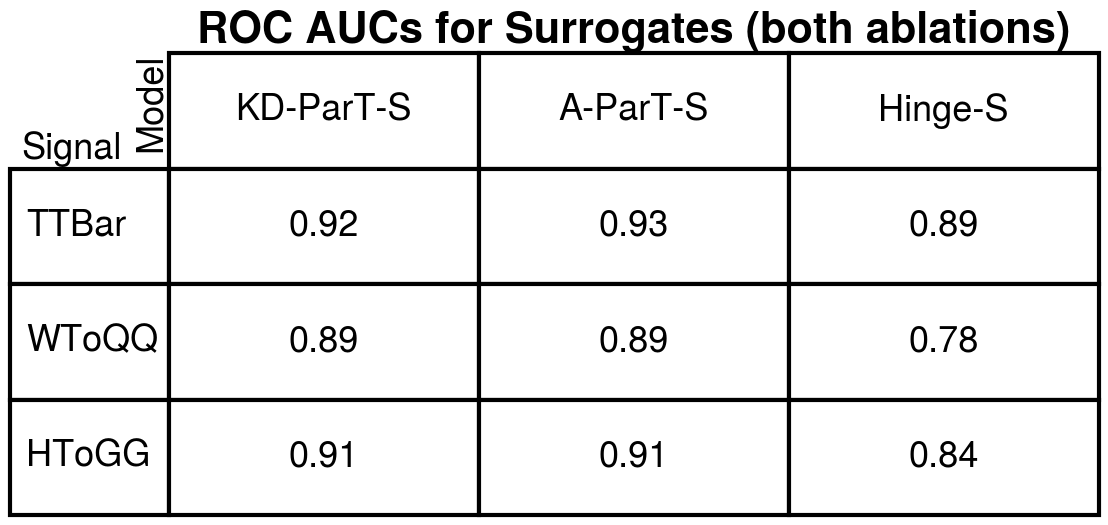

In [70]:
surrogates = ['KD-ParT-S', 'A-ParT-S', 'Hinge-S']

fig, ax = plt.subplots(figsize=(12, 6))

score_dict = {signal: [] for signal in signals}

for signal, models in _model_dicts.items():
    for model_name, data_dict in models.items():
        if model_name not in surrogates:
            continue

        dl_name = model_name[:-2]
        if dl_name == 'PN':
            dl_name='ParticleNet'

        roc_auc = data_dict['classification']['roc_auc'][0]
        score_dict[signal].append(round(roc_auc, 2))

cell_text = list(score_dict.values())
cell_text = np.concatenate((cell_text, [[0.89], [0.78], [0.84]]), axis=1)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

table = ax.table(cellText=cell_text, rowLabels=signals, colLabels=surrogates, cellLoc='center', bbox=[0, 0, 1, 1])
table.scale(1, 1)
ax.set_title(r'ROC AUCs for Surrogates (both ablations)', fontweight='bold')
ax.set_xlabel('Signal')
ax.set_ylabel('Model')
ax.xaxis.set_label_coords(-0.05, 0.83)
ax.yaxis.set_label_coords(0, 1)

for key, cell in table.get_celld().items():
    cell.set_linewidth(3)

plt.show()
fig.savefig(f'{workdir}/figures/M15-COMPARISON_r2scores.png', dpi=300, format='png')

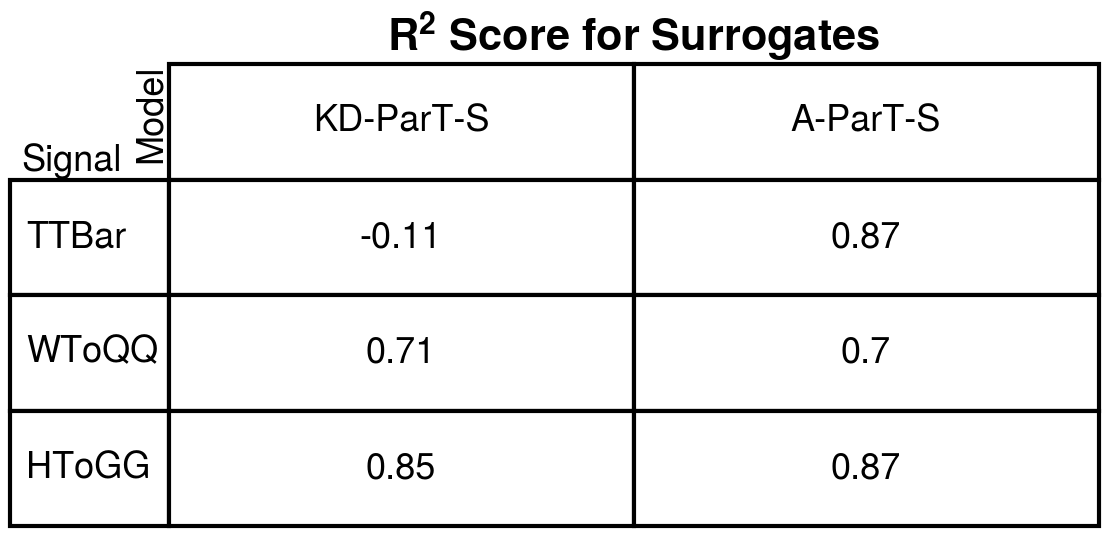

In [71]:
surrogates = ['KD-ParT-S', 'A-ParT-S']

def spearman(teacher_logits, student_logits):

    from scipy.stats import spearmanr

    rho_values = []
    
    for i in range(teacher_logits.shape[-1]):

        rho = spearmanr(student_logits[:, i], teacher_logits[:, i]).statistic
        rho_values.append(rho)
        
    return rho_values

fig, ax = plt.subplots(figsize=(12, 6))

score_dict = {signal: [] for signal in signals}

for signal, models in _model_dicts.items():
    for model_name, data_dict in models.items():
        if model_name not in surrogates:
            continue

        dl_name = model_name[:-2]
        if dl_name == 'PN':
            dl_name='ParticleNet'

        dl_logits = models[dl_name]['preds']['logits']
        surrogate_logits = data_dict['preds']['logits']

        r2_score = faithfulness.r2_score(dl_logits, surrogate_logits)
        score_dict[signal].append(round(r2_score, 2))

cell_text = list(score_dict.values())
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

table = ax.table(cellText=cell_text, rowLabels=signals, colLabels=surrogates, cellLoc='center', bbox=[0, 0, 1, 1])
table.scale(1, 1)
ax.set_title(r'$R^2$ Score for Surrogates', fontweight='bold')
ax.set_xlabel('Signal')
ax.set_ylabel('Model')
ax.xaxis.set_label_coords(-0.05, 0.83)
ax.yaxis.set_label_coords(0, 1)

for key, cell in table.get_celld().items():
    cell.set_linewidth(3)

plt.show()
fig.savefig(f'{workdir}/figures/M15-COMPARISON_r2scores.png', dpi=300, format='png')